In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")
performance = pd.read_csv("../data/processed/cleaned_performance.csv")
transactions = pd.read_csv("../data/processed/cleaned_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [7]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby(
    'amfi_code'
)['nav'].pct_change()

results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]['daily_return'].dropna()

    var95 = np.percentile(temp,5)

    cvar95 = temp[
        temp <= var95
    ].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar.to_csv(
    'var_cvar_report.csv',
    index=False
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


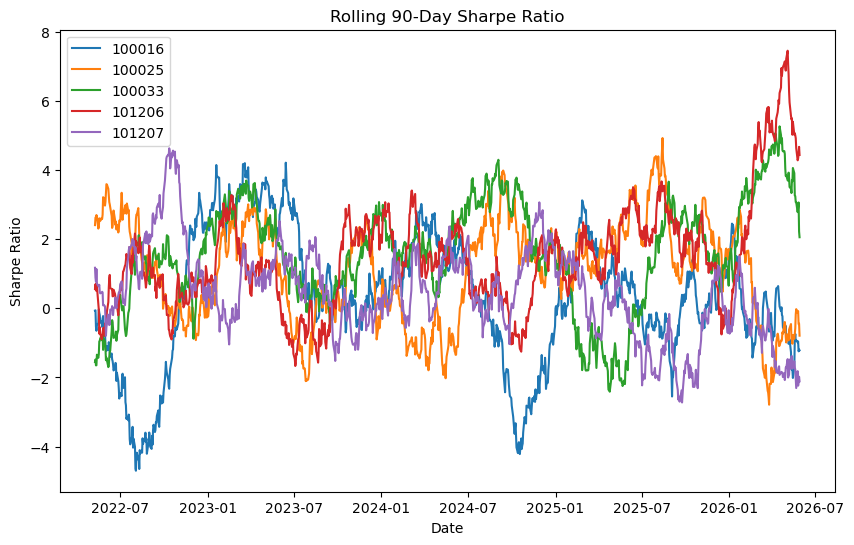

In [8]:
funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(10,6))

for fund in funds:

    temp = nav[
        nav['amfi_code']==fund
    ].copy()

    temp['rolling_sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig(
    "rolling_sharpe_chart.png"
)

plt.show()

In [9]:
sip = transactions[
    transactions['transaction_type']=="SIP"
].copy()

sip['cohort_year'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .transform('min')
    .dt.year
)

cohort = sip.groupby(
    'cohort_year'
).agg({
    'amount_inr':['mean','sum']
})

cohort.to_csv(
    'cohort_analysis.csv'
)

cohort

amount_inr           
                     mean        sum
cohort_year                         
2024         10986.861803  212189262
2025         12516.697270    5044229

In [10]:
sip = sip.sort_values([
    'investor_id',
    'transaction_date'
])

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

continuity = sip.groupby(
    'investor_id'
)['gap_days'].mean().reset_index()

continuity['status'] = np.where(
    continuity['gap_days'] > 35,
    'At Risk',
    'Active'
)

continuity.to_csv(
    'sip_continuity.csv',
    index=False
)

continuity.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Active


In [11]:
holdings['weight_sq'] = (
    holdings['weight_pct'] ** 2
)

hhi = holdings.groupby(
    'amfi_code'
)['weight_sq'].sum().reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.to_csv(
    'sector_hhi.csv',
    index=False
)

hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


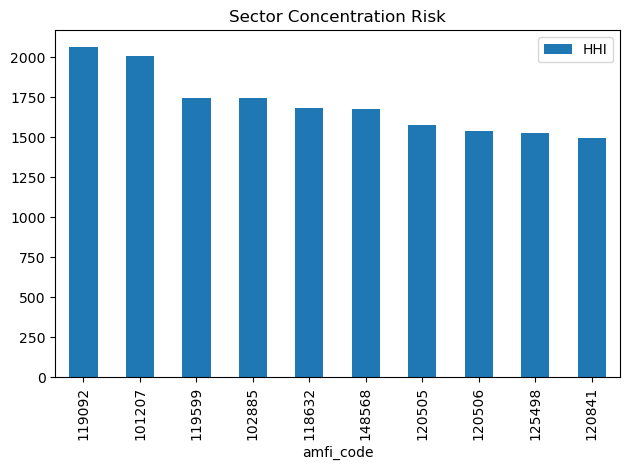

In [12]:
hhi.sort_values(
    'HHI',
    ascending=False
).head(10).plot(
    x='amfi_code',
    y='HHI',
    kind='bar'
)

plt.title(
    "Sector Concentration Risk"
)

plt.tight_layout()
plt.show()

## Key Findings

1. Certain funds exhibit significantly higher VaR and downside risk.
2. Rolling Sharpe ratios indicate notable differences in risk-adjusted performance.
3. The 2025 investor cohort contributed higher investments than previous cohorts.
4. Several SIP investors showed contribution gaps greater than 35 days.
5. Sector concentration risk varies considerably across mutual fund portfolios.